# 2) Implied volatility network: IV-ANN



In [2]:
# Basic imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Updating scipy to use module QMC for Latin hypercube sampling
#!pip install scipy==1.7
from scipy.stats import qmc

# Pytorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR, LinearLR, OneCycleLR, LambdaLR

In [3]:
def bs_price_call(S, K, T, t, r, sigma):
  """
  Black-Scholes call option value price related to PDE (2). Returns option's price.
  S:     spot price
  K:     strike price
  T:     time to maturity
  t:     spot time
  r:     interest rate
  sigma: volatility of underlying asset
  """

  # Boundary condition of Black-Sholes PDE (2)
  if T == t:
    return np.maximum(0, S - K)  
  # Solution of the PDE (2) on the open interval [t, T)
  else : 
    d1 = ( np.log(S / K) + (r + 0.5 * sigma ** 2) * (T-t) ) / (sigma * np.sqrt(T-t))
    d2 = d1 - sigma*np.sqrt(T-t)
    value = S * norm.cdf(d1) - K * np.exp(-r * (T-t)) * norm.cdf(d2) 
  
  return value

def bs_moneyness_call(moneyness, tau, r, sigma):
  """
  Same function as bs_price_call but in terms of moneyness. Returns V/K and 
  has S/K instead of two seperate paremeters S and K.
  moneyness: S/K
  Tau: time to maturity minus spot time
  r: interest rate
  sigma: volatility of underlying asset
  """

  d1 = ( np.log(moneyness) + (r + 0.5 * sigma ** 2) * (tau) ) / (sigma * np.sqrt(tau))
  d2 = d1 - sigma*np.sqrt(tau)
  value_moneyness = moneyness * norm.cdf(d1) - np.exp(-r * (tau)) * norm.cdf(d2) 
  
  return value_moneyness

In [4]:
class BS_ANN(nn.Module):
  def __init__(self):
    """
    Initilize BS-ANN netwwork with four hidden layers. 
    Same architecture as the one used in table 2.
    Weight are initialized using Glorot_uniform also known as Xavier_uniform.
    """
    super(BS_ANN, self).__init__()
    # 4 layers
    self.fc1 = nn.Linear(4, 400)
    self.fc2 = nn.Linear(400, 400)
    self.fc3 = nn.Linear(400, 400)
    self.fc4 = nn.Linear(400, 400)
    self.fc5 = nn.Linear(400, 1)
    # initilizing the layer's weights
    torch.nn.init.xavier_uniform_(self.fc1.weight)
    torch.nn.init.xavier_uniform_(self.fc2.weight)
    torch.nn.init.xavier_uniform_(self.fc3.weight)
    torch.nn.init.xavier_uniform_(self.fc4.weight)
    torch.nn.init.xavier_uniform_(self.fc5.weight)


  def forward(self, x):
    """
    Foward pass of the network. 
    Relu activations are used and a linear activation is used in the final layer.
    x: input torch tensor (CUDA or CPU)
    """
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = F.relu(self.fc4(x))
    x = self.fc5(x)
    return x.flatten()

  def train_model(self, args, device, train_loader, optimizer, epoch):
    """
    Training over train_loader batches for one epoch.
    Returns average training loss.
    args: training parameters.
    device: CUDA or CPU.
    train_loader: train data loader.
    optimizer: gradient descent optmizer.
    epoch: current epoch.
    """
    # train mode
    self.train()
    train_loss = 0
    # loop over data loader
    for batch_idx, data in enumerate(train_loader):
      # extracting the inputs and target
      data, target = data[:,:-1].to(device), data[:,-1].to(device)
      # zeroing the gradients
      optimizer.zero_grad()
      # foward pass
      output = self(data)
      # computing the loss
      loss = F.mse_loss(output, target)
      train_loss += loss.item() *data.shape[0]
      # back propagation
      loss.backward()
      # updating the optimizer step
      optimizer.step()
      # printing batch information
      if batch_idx % args["log_interval"] == 0:
        print('Train Epoch: {} [{}/{} ({:.0f}%)]\tlog Loss: {:.6f}'.format(
            epoch, int(batch_idx / len(train_loader)*len(train_loader.dataset)), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), np.log(loss.item())))
        if args["dry_run"]:
          break
    train_loss /= len(train_loader.dataset)
    print('\nTrain set: Average log loss: {:.4f}\n'.format(np.log(train_loss))) 
    return train_loss


  def test_model(self, device, test_loader):
    """
    Testing over test_loader batches for one epoch. 
    Returns average test loss.
    device: CUDA or CPU.
    test_loader: test data loader.
    """
    # evaluation mode
    self.eval()
    test_loss = 0
    # freezing the gradients
    with torch.no_grad():
      # looping over the test laoder
      for data in test_loader:
        # extracting the inputs and target
        data, target = data[:,:-1].to(device), data[:,-1].to(device)
        # foward pass
        output = self(data)
        #computing the loss
        test_loss += F.mse_loss(output, target, reduction='sum').item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}\n'.format(np.log(test_loss))) 
    return test_loss

### Defining class IV-ANN 

In [5]:
class IV_ANN(BS_ANN):
    # The authors of the paper seem to use
    # the same architecture both for BS-ANN and the IV-ANN
    # thus the class inherets from BS_ANN
  pass

### Data Generation with log transformation

Log transformation 

$\tilde{V}=V_{t}-\max \left(S_{t}-K e^{-r \tau}, 0\right)$

$\left\{\log (\tilde{V} / K), S_{0} / K, r, \tau\right\}$

In [6]:
def IV_LHS_data_generator(n = 10**6, l_bounds = [.5, .05, .0, .05], u_bounds = [1.4, 1, .1, 1], log_scale = True):
  """
  Generates samples of call prices using Latin hypercube sampling.
  Returns a torch float tensor of dimension (n,5) containig the inputs samples and the volatility as the target.
  Performs a log transormation of V/K.
  The inputs are: Moneyness (S/K), time to maturity (tau), Risk free rate (r), Volatility (sigma).
  n: number of samples.
  l_bounds: lower bound for the inputs.  
  u_bounds: upper bound for the inputs.
  log_scale: performs log transformation if True.

  """
  sampler = qmc.LatinHypercube(d = 4)
  sample = sampler.random(n)
  sample = qmc.scale(sample, l_bounds, u_bounds)
  bs_prices = bs_moneyness_call(sample[:,0], sample[:,1], sample[:,2], sample[:,3]).reshape((-1, 1))
  bs_dataset = np.concatenate((sample[:,:-1], bs_prices, sample[:,3].reshape((n, 1))), axis = 1)

  # log transformation as in section 4.3
  if log_scale : 
    # Calculate intrinsic value
    bs_dataset[:,3] = bs_dataset[:,3] - np.maximum(bs_dataset[:,0] - np.exp(-bs_dataset[:,2] * bs_dataset[:,1]), 0)
    # Discard samples where time value is too small or negative
    indecies = np.argwhere(bs_dataset[:,3] < 1e-7)
    bs_dataset = np.delete(bs_dataset, indecies, 0)
    # Log transformation
    bs_dataset[:,3] = np.log(bs_dataset[:,3])
    print("log(V/K) after transformation: [{:.2f}, {:.2f}]".format(min(bs_dataset[:,3]), max(bs_dataset[:,3])))
  print("------ INPUT ------")
  print("S/K.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,0]), max(bs_dataset[:,0])))
  print("Tau.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,1]), max(bs_dataset[:,1])))
  print("r............ [{:.2f} {:.2f}]".format(min(bs_dataset[:,2]), max(bs_dataset[:,2])))
  if log_scale : 
    print("log(V/K)..... [{:.2f} {:.2f}]".format(min(bs_dataset[:,3]), max(bs_dataset[:,3])))
  else : 
    print("V/K.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,3]), max(bs_dataset[:,3])))
  print("------ OUTPUT ------")
  print("Sigma........ [{:.2f} {:.2f}]".format(min(bs_dataset[:,4]), max(bs_dataset[:,4])))
  return torch.FloatTensor(bs_dataset)

bs_dataset = IV_LHS_data_generator(log_scale = True)

log(V/K) after transformation: [-16.12, -0.98]
------ INPUT ------
S/K.......... [0.50 1.40]
Tau.......... [0.05 1.00]
r............ [0.00 0.10]
log(V/K)..... [-16.12 -0.98]
------ OUTPUT ------
Sigma........ [0.05 1.00]


### Training IV-ANN with log transofmation

In [7]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 3*10**3,
         "lr": 1e-4,
         "gamma": .1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}

use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])

# Loading Train / Test Data
bs_dataset = IV_LHS_data_generator(n = 10**5, log_scale = True)
train_size, test_size = int(bs_dataset.shape[0]*0.9), int(bs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, bs_dataset.shape[0]-train_size])

train_loader = torch.utils.data.DataLoader(train_dataset,args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])

# Model training
print(device)
model = IV_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) # Adam is found to be the best optimizer in the article
scheduler = StepLR(optimizer, step_size=10**3, gamma=args["gamma"]) # Deacreses the Learning rate by .1 every 1000 epoch

train_losses = []
test_losses = []
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "IV_SCALED_ANN.pt")
    

log(V/K) after transformation: [-16.12, -1.00]
------ INPUT ------
S/K.......... [0.50 1.40]
Tau.......... [0.05 1.00]
r............ [0.00 0.10]
log(V/K)..... [-16.12 -1.00]
------ OUTPUT ------
Sigma........ [0.05 1.00]
cuda
Train Epoch: 1 [0/84996 (0%)]	log Loss: -1.332471

Train set: Average log loss: -3.1281


Test set: Average loss: -3.5987

Current Learning rate 0.0001
Train Epoch: 2 [0/84996 (0%)]	log Loss: -3.520392

Train set: Average log loss: -3.8494


Test set: Average loss: -3.8194

Current Learning rate 0.0001
Train Epoch: 3 [0/84996 (0%)]	log Loss: -3.718596

Train set: Average log loss: -4.1255


Test set: Average loss: -4.0498

Current Learning rate 0.0001
Train Epoch: 4 [0/84996 (0%)]	log Loss: -3.942084

Train set: Average log loss: -4.6365


Test set: Average loss: -5.1456

Current Learning rate 0.0001
Train Epoch: 5 [0/84996 (0%)]	log Loss: -5.110309

Train set: Average log loss: -5.5468


Test set: Average loss: -4.9750

Current Learning rate 0.0001
Train Epoch: 6

In [67]:
# Loading model from saved weights
device = torch.device("cuda")
loaded_IV_ANN = IV_ANN().to(device)
PATH = "ANN_weights/IV_SCALED_ANN.pt"
loaded_IV_ANN.load_state_dict(torch.load(PATH))
loaded_IV_ANN.eval()


IV_ANN(
  (fc1): Linear(in_features=4, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=400, bias=True)
  (fc5): Linear(in_features=400, out_features=1, bias=True)
)

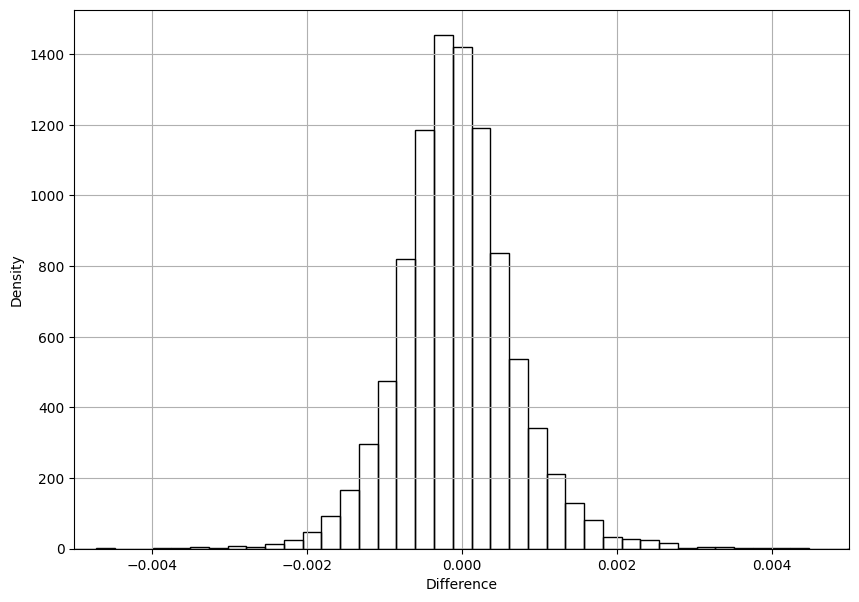

MAX  0.0059313327
MIN  -0.018266499
Range of errors:  -0.018266499 0.0059313327


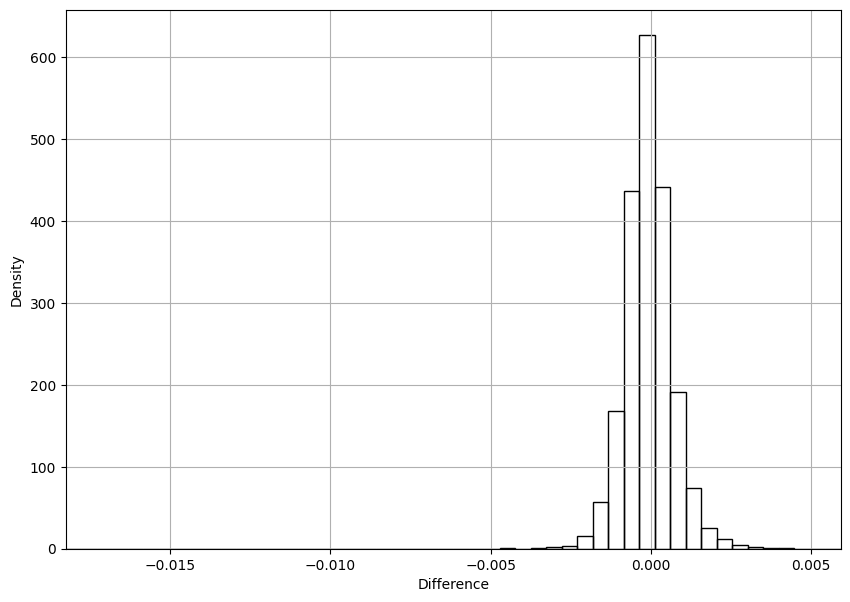

MAX  0.0059313327
MIN  -0.018266499
Mean error: -7.356041169259697e-05
Median error: -9.66191291809082e-05
Standard deviation: 0.0007803718908689916


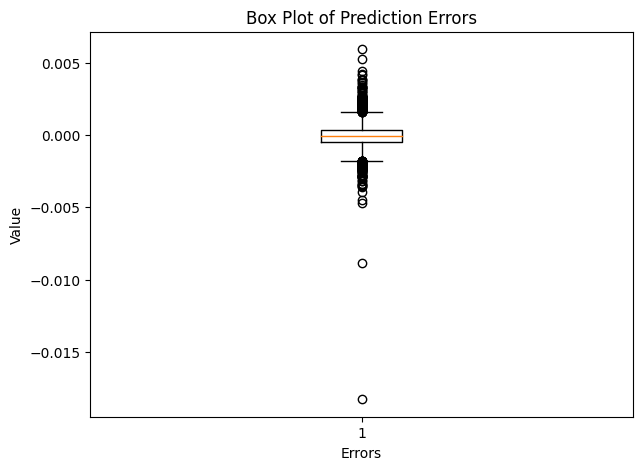

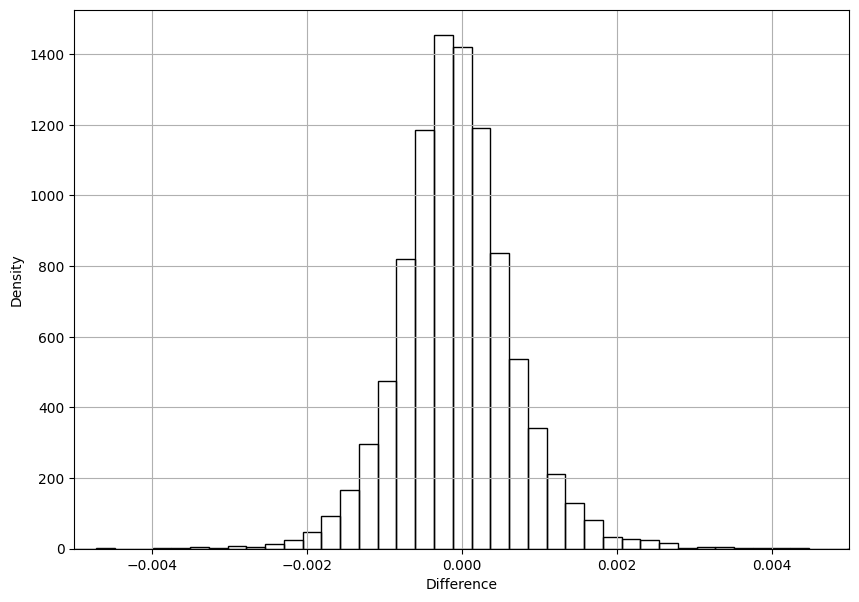

MAX  0.0059313327
MIN  -0.018266499


In [57]:
# Plotting erros histogram
errors = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN(data)
    errors.append((target-output).data.cpu().numpy())
  errors = np.concatenate(errors)
plt.figure(figsize=(10,7))
plt.hist(errors,100,fill=False)
plt.grid()
plt.xlabel("Difference")
plt.ylabel("Density")
plt.xlim([-0.005, 0.005])
plt.show()
print("MAX ",errors.max())
print("MIN ",errors.min())
# Plotting erros histogram
errors = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN(data)
    errors.append((target-output).data.cpu().numpy())
  errors = np.concatenate(errors)
  
plt.figure(figsize=(10,7))
#plt.hist(errors,100,fill=False, density=True) origin
plt.hist(errors, bins=50, fill=False, density=True)  # Try fewer bins
plt.grid()
plt.xlabel("Difference")
plt.ylabel("Density")

# plt.xlim([-0.005, 0.005]) #origin
plt.xlim([errors.min(), errors.max()])  # Set xlim based on data range
plt.show()
print("MAX ",errors.max())
print("MIN ",errors.min())

print(f"Mean error: {np.mean(errors)}")
print(f"Median error: {np.median(errors)}")
print(f"Standard deviation: {np.std(errors)}")
plt.figure(figsize=(7,5))
plt.boxplot(errors)
plt.xlabel("Errors")
plt.ylabel("Value")
plt.title("Box Plot of Prediction Errors")
plt.show()


# Plotting erros histogram
errors = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN(data)
    errors.append((target-output).data.cpu().numpy())
  errors = np.concatenate(errors)
plt.figure(figsize=(10,7))
plt.hist(errors,100,fill=False)
plt.grid()
plt.xlabel("Difference")
plt.ylabel("Density")
plt.xlim([-0.005, 0.005])
plt.show()
print("MAX ",errors.max())
print("MIN ",errors.min())


In [21]:
# Printing train and test MSE, MAE, MAPE and R2
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Train scores----------------
MSE 6.033652e-07
MAE 5.622620e-04
MAPE 1.537563e-03
R2 9.999913e-01
-----------Test scores----------------
MSE 6.594335e-07
MAE 5.705318e-04
MAPE 1.514891e-03
R2 9.999905e-01


### Training IV-ANN without log transofmation

In [58]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 3*10**3,
         "lr": 1e-4,
         "gamma": .1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}



use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])


# Train / Test Data
bs_dataset = IV_LHS_data_generator(n = 10**5, log_scale = False)
train_size, test_size = int(bs_dataset.shape[0]*0.9), int(bs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, bs_dataset.shape[0]-train_size])

train_loader = torch.utils.data.DataLoader(train_dataset,args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])


# Model training
print(device)
model = BS_ANN().to(device)
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) # Adam is found to be the best optimizer in the article
scheduler = StepLR(optimizer, step_size=10**3, gamma=args["gamma"]) # Deacreses the Learning rate by .1 every 1000 epoch

train_losses = []
test_losses = []
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "IV_UNSCALED_ANN.pt")
    

------ INPUT ------
S/K.......... [0.50 1.40]
Tau.......... [0.05 1.00]
r............ [0.00 0.10]
V/K.......... [0.00 0.71]
------ OUTPUT ------
Sigma........ [0.05 1.00]
cuda
Train Epoch: 1 [0/90000 (0%)]	log Loss: -0.619784

Train set: Average log loss: -2.3766


Test set: Average loss: -2.6369

Current Learning rate 0.0001
Train Epoch: 2 [0/90000 (0%)]	log Loss: -2.593717

Train set: Average log loss: -2.6835


Test set: Average loss: -2.7679

Current Learning rate 0.0001
Train Epoch: 3 [0/90000 (0%)]	log Loss: -2.719701

Train set: Average log loss: -2.9811


Test set: Average loss: -3.3389

Current Learning rate 0.0001
Train Epoch: 4 [0/90000 (0%)]	log Loss: -3.232392

Train set: Average log loss: -3.5647


Test set: Average loss: -3.8411

Current Learning rate 0.0001
Train Epoch: 5 [0/90000 (0%)]	log Loss: -3.705373

Train set: Average log loss: -3.9905


Test set: Average loss: -4.1654

Current Learning rate 0.0001
Train Epoch: 6 [0/90000 (0%)]	log Loss: -4.043544

Train set: Av

KeyboardInterrupt: 

In [23]:
# Loading model
device = torch.device("cuda")
loaded_IV_ANN_UN = IV_ANN().to(device)
PATH = "ANN_weights/IV_UNSCALED_ANN.pt"
loaded_IV_ANN_UN.load_state_dict(torch.load(PATH))
loaded_IV_ANN_UN.eval()


IV_ANN(
  (fc1): Linear(in_features=4, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=400, bias=True)
  (fc5): Linear(in_features=400, out_features=1, bias=True)
)

MAX  9085.556
MIN  590.5707


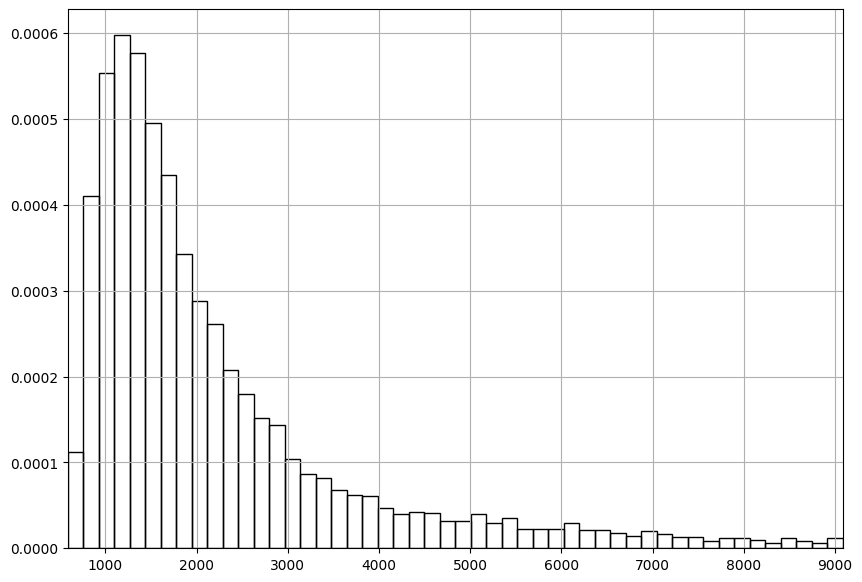

In [50]:
# Plotting erros histogram
errors = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN_UN(data)
    errors.append((target-output).data.cpu().numpy())
  errors = np.concatenate(errors)
plt.figure(figsize=(10,7))
#h = plt.hist(errors,100)
plt.hist(errors, bins=50, fill=False, density=True)  # Try fewer bins
plt.xlim([errors.min(), errors.max()])  # Set xlim based on data range
plt.grid()
print("MAX ",errors.max())
print("MIN ",errors.min())


In [14]:
# Printing train and test MSE, MAE, MAPE and R2
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN_UN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MSE {:e}".format(np.sqrt(mean_squared_error(outputs,targets))) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_IV_ANN_UN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("RMSE {:e}".format(np.sqrt(mean_squared_error(outputs,targets))) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Train scores----------------
MSE 6.186769e-04
MSE 2.487322e-02
MAE 8.043725e-03
MAPE 3.845526e-02
R2 9.916103e-01
-----------Test scores----------------
MSE 6.307160e-04
RMSE 2.511406e-02
MAE 8.186296e-03
MAPE 3.822103e-02
R2 9.913890e-01
